# Proyecto final: forecasting de producción eléctrica

**Autor:** Juan Daniel Barboza  
**Materia:** Series Temporales  
**Etapa 1:** preparación del dataset, análisis exploratorio y definición del protocolo de evaluación

El objetivo del proyecto es pronosticar el índice mensual de producción eléctrica y comparar, bajo el mismo protocolo temporal, un modelo estadístico SARIMA y un modelo de Machine Learning XGBoost. En esta primera etapa todavía no se entrenan modelos.

## Decisiones metodológicas previas

Para evitar una comparación injusta entre alternativas, se fija el protocolo antes de modelar:

- No se compararán ventanas de entrenamiento de diferente longitud.
- SARIMA y XGBoost se evaluarán sobre los mismos meses y el mismo horizonte.
- `validation` se usará para seleccionar configuraciones.
- `test` permanecerá intocable hasta la evaluación final.
- Las métricas finales se calcularán en la escala original de la serie.
- Las métricas obligatorias serán RMSE, MAE y MAPE.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def locate_project_root():
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'data' / 'Electric_Production.csv').exists():
            return candidate.resolve()
    raise FileNotFoundError(
        'No se encontró data/Electric_Production.csv. '        'Ejecuta el notebook desde la raíz del proyecto o desde notebooks/.'
    )

PROJECT_ROOT = locate_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'Electric_Production.csv'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raíz del proyecto: {PROJECT_ROOT}')
print(f'Dataset: {DATA_PATH}')

Raíz del proyecto: C:\Users\jdani\Documents\codex_sandbox\Tareas MScIA\Time Series\Proyecto Final
Dataset: C:\Users\jdani\Documents\codex_sandbox\Tareas MScIA\Time Series\Proyecto Final\data\Electric_Production.csv


## 1. Carga y validación del dataset

La columna `DATE` contiene la marca temporal mensual y `IPG2211A2N` es la variable numérica que se desea pronosticar. Las comprobaciones siguientes detienen la ejecución si la estructura no coincide con la esperada.

In [2]:
raw = pd.read_csv(DATA_PATH)
expected_columns = {'DATE', 'IPG2211A2N'}
if set(raw.columns) != expected_columns:
    raise ValueError(f'Columnas inesperadas: {list(raw.columns)}')

df = raw.rename(columns={'DATE': 'date', 'IPG2211A2N': 'production'}).copy()
df['date'] = pd.to_datetime(df['date'], errors='raise')
df['production'] = pd.to_numeric(df['production'], errors='raise')
df = df.sort_values('date').set_index('date')

if df.index.has_duplicates:
    raise ValueError('Se encontraron fechas duplicadas.')
if not df.index.is_monotonic_increasing:
    raise ValueError('Las fechas no están ordenadas.')
if (df['production'] <= 0).any():
    raise ValueError('La serie contiene valores no positivos; MAPE debe revisarse.')

full_index = pd.date_range(df.index.min(), df.index.max(), freq='MS')
missing_dates = full_index.difference(df.index)
if len(missing_dates):
    raise ValueError(f'Faltan {len(missing_dates)} meses en la serie.')

df = df.asfreq('MS')
series = df['production']
assert len(series) >= 100, 'La consigna exige al menos 100 observaciones.'

display(df.head())
display(df.tail())

,production
date,
1985-01-01,71.5943
1985-02-01,69.7893
1985-03-01,61.6809
1985-04-01,56.7497
1985-05-01,54.6182


,production
date,
2017-09-01,95.8099
2017-10-01,90.8122
2017-11-01,95.7451
2017-12-01,114.4277
2018-01-01,126.3765


In [3]:
quality_summary = pd.Series({
    'observaciones': len(series),
    'fecha_inicial': series.index.min().date(),
    'fecha_final': series.index.max().date(),
    'frecuencia': series.index.freqstr,
    'fechas_duplicadas': int(series.index.duplicated().sum()),
    'meses_faltantes': int(len(missing_dates)),
    'valores_faltantes': int(series.isna().sum()),
    'valor_minimo': round(series.min(), 4),
    'valor_maximo': round(series.max(), 4),
    'media': round(series.mean(), 4),
    'desviacion_estandar': round(series.std(), 4),
}, name='resultado')
quality_summary.to_frame()

,resultado
observaciones,397
fecha_inicial,1985-01-01
fecha_final,2018-01-01
frecuencia,MS
fechas_duplicadas,0
meses_faltantes,0
valores_faltantes,0
valor_minimo,54.6182
valor_maximo,126.3765
media,87.6536


## 2. Serie temporal original

Esta visualización permite identificar cambios de nivel, tendencia, estacionalidad y posibles observaciones atípicas. No se eliminarán valores únicamente por parecer extremos: cualquier tratamiento deberá justificarse en el contexto temporal.

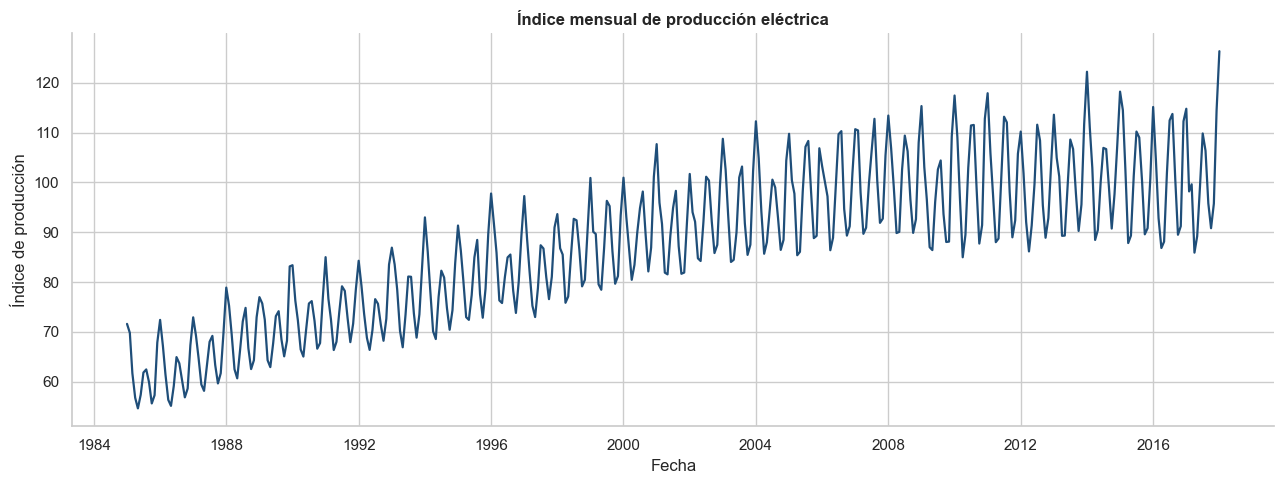

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(series.index, series, color='#1f4e79', linewidth=1.6)
ax.set(
    title='Índice mensual de producción eléctrica',
    xlabel='Fecha',
    ylabel='Índice de producción',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_serie_original.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. Patrón estacional mensual

Se compara la distribución de la producción para cada mes del año. Un patrón que se repite cada 12 meses justificaría incorporar estacionalidad anual en SARIMA y rezagos estacionales en XGBoost.

,mean,std,min,max
Ene,100.78,15.74,71.59,126.38
Feb,92.85,13.59,67.15,114.53
Mar,86.71,12.48,61.46,102.90
Abr,77.99,10.53,56.34,89.85
May,78.27,11.89,54.62,91.35
Jun,86.23,14.36,57.35,102.92
Jul,93.73,15.91,61.82,113.21
Ago,93.96,15.72,62.44,113.77
Sep,85.32,13.09,59.84,100.72
Oct,79.08,11.39,55.61,91.89


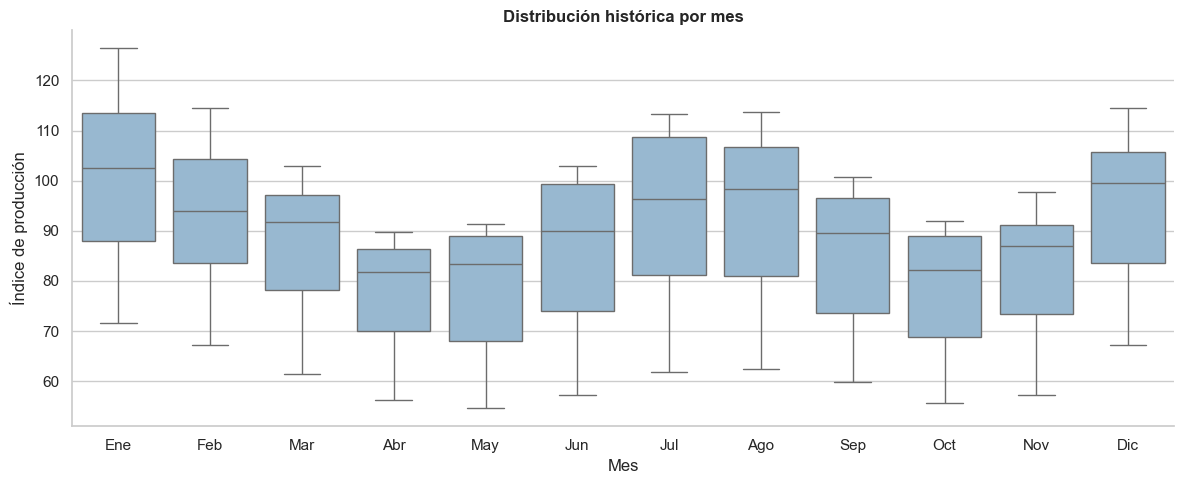

In [5]:
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
seasonal_df = df.assign(
    month=df.index.month,
    year=df.index.year,
)
monthly_profile = seasonal_df.groupby('month')['production'].agg(['mean', 'std', 'min', 'max'])
monthly_profile.index = month_names
display(monthly_profile.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=seasonal_df, x='month', y='production',
    color='#8fb9d9', showfliers=True, ax=ax,
)
ax.set_xticklabels(month_names)
ax.set(
    title='Distribución histórica por mes',
    xlabel='Mes',
    ylabel='Índice de producción',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_estacionalidad_mensual.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Descomposición estacional

La descomposición separa la serie observada en tendencia, estacionalidad y residuo. Se usa una forma multiplicativa porque la serie es estrictamente positiva y permite inspeccionar si la amplitud estacional cambia con el nivel. Esta visualización es descriptiva; todavía no determina automáticamente la especificación de SARIMA.

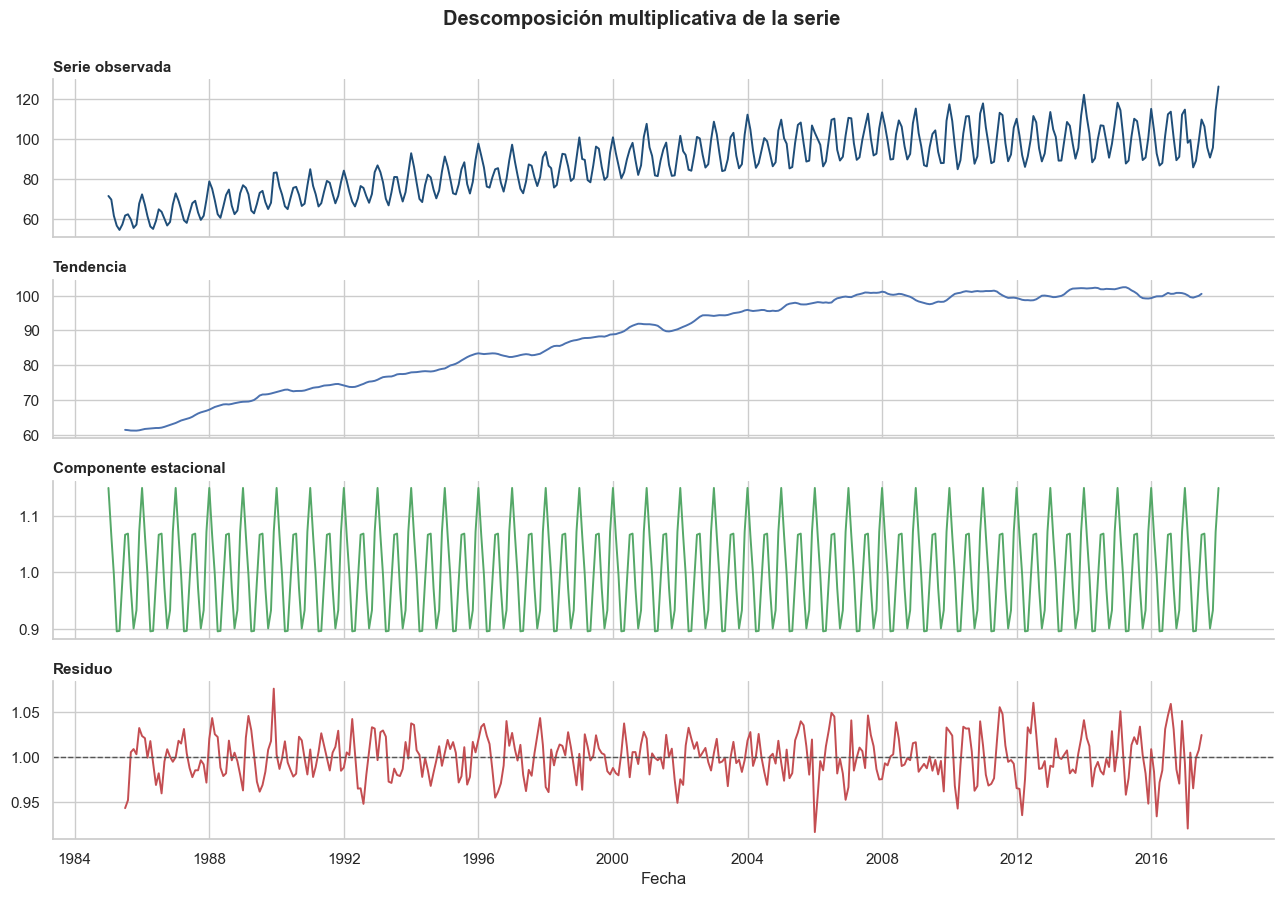

In [6]:
decomposition = seasonal_decompose(series, model='multiplicative', period=12)
components = [
    ('Serie observada', decomposition.observed, '#1f4e79'),
    ('Tendencia', decomposition.trend, '#4c72b0'),
    ('Componente estacional', decomposition.seasonal, '#55a868'),
    ('Residuo', decomposition.resid, '#c44e52'),
]
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, (title, values, color) in zip(axes, components):
    ax.plot(values, color=color, linewidth=1.4)
    ax.set_title(title, loc='left', fontsize=11)
    if title == 'Residuo':
        ax.axhline(1.0, color='#555555', linestyle='--', linewidth=1)
axes[-1].set_xlabel('Fecha')
fig.suptitle('Descomposición multiplicativa de la serie', y=0.995, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_descomposicion.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Estabilidad de la variabilidad y transformación logarítmica

La transformación logarítmica puede ser útil cuando la variabilidad crece junto con el nivel. Se comparan media y desviación estándar móviles en escala original y logarítmica. La decisión final se tomará antes de ajustar los modelos y cualquier pronóstico transformado se devolverá a la escala original para evaluarlo.

,correlacion
correlacion_media_desviacion_original,0.910
correlacion_media_desviacion_log,0.434


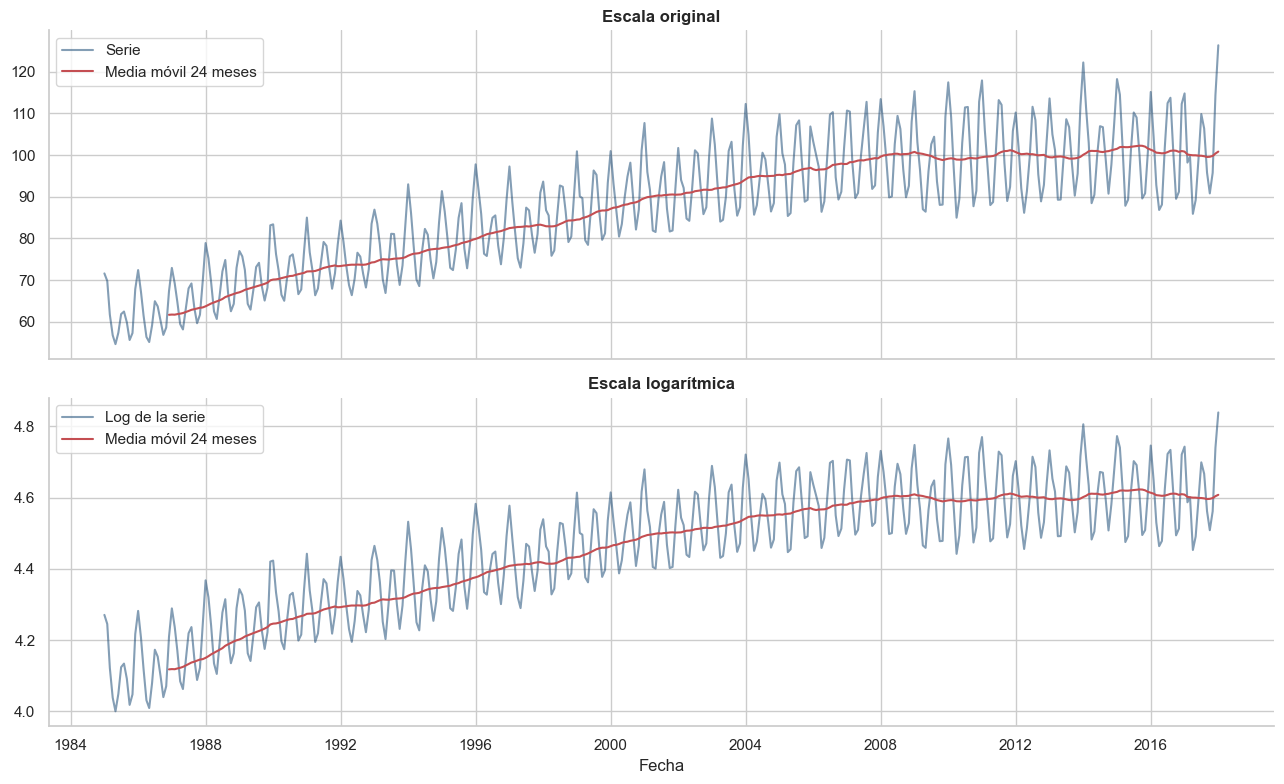

In [7]:
log_series = np.log(series)
window = 24
rolling_original = pd.DataFrame({
    'media': series.rolling(window).mean(),
    'desviacion': series.rolling(window).std(),
}).dropna()
rolling_log = pd.DataFrame({
    'media': log_series.rolling(window).mean(),
    'desviacion': log_series.rolling(window).std(),
}).dropna()

variance_diagnostic = pd.Series({
    'correlacion_media_desviacion_original': rolling_original.corr().loc['media', 'desviacion'],
    'correlacion_media_desviacion_log': rolling_log.corr().loc['media', 'desviacion'],
}, name='correlacion').round(3)
display(variance_diagnostic.to_frame())

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(series, color='#1f4e79', alpha=0.55, label='Serie')
axes[0].plot(rolling_original['media'], color='#c44e52', label='Media móvil 24 meses')
axes[0].set_title('Escala original')
axes[0].legend()
axes[1].plot(log_series, color='#1f4e79', alpha=0.55, label='Log de la serie')
axes[1].plot(rolling_log['media'], color='#c44e52', label='Media móvil 24 meses')
axes[1].set_title('Escala logarítmica')
axes[1].set_xlabel('Fecha')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_transformacion_log.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Diagnóstico de estacionariedad

La prueba ADF contrasta la presencia de raíz unitaria. Un valor p pequeño aporta evidencia de estacionariedad. Se inspeccionan la serie original, la primera diferencia y la diferencia estacional de 12 meses. Esta prueba será una referencia para proponer `d` y `D`, no una regla automática.

In [8]:
def adf_summary(values, label):
    values = pd.Series(values).dropna()
    statistic, p_value, used_lags, n_obs, critical_values, _ = adfuller(values, autolag='AIC')
    return {
        'serie': label,
        'estadistico_adf': statistic,
        'p_value': p_value,
        'rezagos_usados': used_lags,
        'observaciones': n_obs,
        'critico_5%': critical_values['5%'],
    }

adf_results = pd.DataFrame([
    adf_summary(log_series, 'log original'),
    adf_summary(log_series.diff(), 'log diferencia 1'),
    adf_summary(log_series.diff(12), 'log diferencia estacional 12'),
    adf_summary(log_series.diff().diff(12), 'log diferencia 1 + estacional 12'),
]).set_index('serie')
adf_results.round(4)

,estadistico_adf,p_value,rezagos_usados,observaciones,critico_5%
serie,,,,,
log original,-3.2373,0.0179,15,381,-2.8692
log diferencia 1,-6.7838,0.0000,14,381,-2.8692
log diferencia estacional 12,-5.1829,0.0000,12,372,-2.8693
log diferencia 1 + estacional 12,-8.1938,0.0000,15,368,-2.8694


## 7. División temporal fija

Se reservan 24 meses para `validation` y 24 para `test`. Este corte será idéntico para todos los modelos y configuraciones. Las observaciones no se mezclan ni se seleccionan aleatoriamente.

In [9]:
VALIDATION_SIZE = 24
TEST_SIZE = 24

train = series.iloc[:-(VALIDATION_SIZE + TEST_SIZE)].copy()
validation = series.iloc[-(VALIDATION_SIZE + TEST_SIZE):-TEST_SIZE].copy()
test = series.iloc[-TEST_SIZE:].copy()

assert len(train) + len(validation) + len(test) == len(series)
assert train.index.max() < validation.index.min() < test.index.min()

split_summary = pd.DataFrame({
    'observaciones': [len(train), len(validation), len(test)],
    'inicio': [train.index.min(), validation.index.min(), test.index.min()],
    'fin': [train.index.max(), validation.index.max(), test.index.max()],
}, index=['train', 'validation', 'test'])
split_summary

,observaciones,inicio,fin
train,349,1985-01-01,2014-01-01
validation,24,2014-02-01,2016-01-01
test,24,2016-02-01,2018-01-01


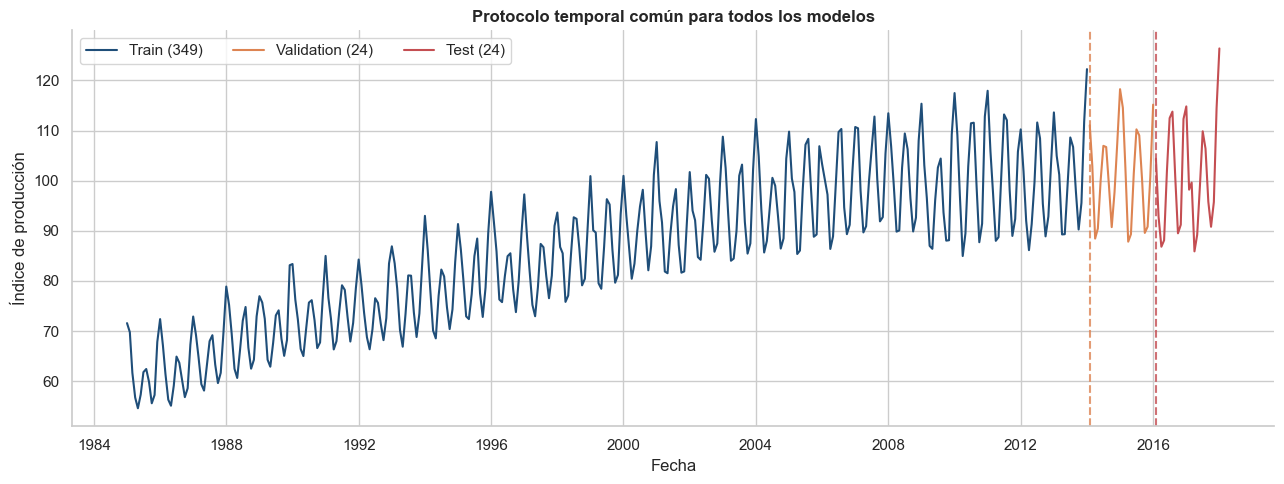

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train, color='#1f4e79', label=f'Train ({len(train)})')
ax.plot(validation, color='#dd8452', label=f'Validation ({len(validation)})')
ax.plot(test, color='#c44e52', label=f'Test ({len(test)})')
ax.axvline(validation.index.min(), color='#dd8452', linestyle='--', alpha=0.8)
ax.axvline(test.index.min(), color='#c44e52', linestyle='--', alpha=0.8)
ax.set(
    title='Protocolo temporal común para todos los modelos',
    xlabel='Fecha',
    ylabel='Índice de producción',
)
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_splits_temporales.png', dpi=180, bbox_inches='tight')
plt.show()

## Conclusiones y punto de control de la etapa 1

1. El dataset contiene 397 observaciones mensuales entre enero de 1985 y enero de 2018, sin fechas duplicadas, meses faltantes ni valores nulos.
2. La serie presenta una tendencia creciente de largo plazo y un patrón anual claro. Enero tiene el promedio mensual más alto (100,78) y abril el más bajo (77,99), lo que respalda un período estacional de 12 meses.
3. La correlación entre media y desviación móvil baja de 0,910 en la escala original a 0,434 en escala logarítmica. Se adoptará el logaritmo como escala de modelado y todas las predicciones se devolverán a la escala original antes de calcular métricas.
4. La prueba ADF aporta evidencia de estacionariedad en las variantes analizadas, pero no se fijarán `d` y `D` solo con esa prueba. Una grilla pequeña con valores 0 y 1 se seleccionará exclusivamente mediante validation para evitar sobrediferenciación.
5. El protocolo queda fijado en 349 observaciones de train, 24 de validation y 24 de test. Todos los modelos usarán los mismos cortes y el mismo horizonte.
6. Test no se utilizará para seleccionar transformaciones, órdenes, rezagos ni hiperparámetros. El siguiente paso será implementar y seleccionar SARIMA usando únicamente train y validation.